In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the data
df = pd.read_csv('/content/car_prices.csv')

df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
#Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [ ]:
#Statistical Summary
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
year,472325.0,2010.210980,3.822151,1990.0,2008.0,2012.0,2013.0,2015.0
condition,472325.0,30.774177,13.286866,1.0,24.0,35.0,41.0,49.0
odometer,472325.0,66701.732040,51939.586894,1.0,28137.0,51085.0,96590.0,999999.0
mmr,472325.0,13837.058964,9532.229273,25.0,7425.0,12300.0,18300.0,182000.0
sellingprice,472325.0,13690.512058,9613.033738,1.0,7200.0,12200.0,18200.0,230000.0
Year2,472325.0,2014.922111,0.267997,2014.0,2015.0,2015.0,2015.0,2015.0


In [ ]:
#Check for the Missing Value
df.isnull().sum()

,0
year,0
make,10301
model,10399
trim,10651
body,13195
transmission,65352
vin,4
state,0
condition,11820
odometer,94


In [ ]:
df=df.dropna()

In [ ]:
from datetime import datetime

def convertdate(date_string):

  # Adjusting the date string to ignore the timezone and handle the rest of the format
  #date_string = "Tue Dec 16 2014 12:30:00 GMT-0800 (PST)"

  # Removing the timezone part for easier parsing
  date_string_modified = date_string.split(' (')[0]

  # Parsing the date string to a datetime object
  date_object = datetime.strptime(date_string_modified, '%a %b %d %Y %H:%M:%S %Z%z')

  # Extracting year, month, and day
  year = date_object.year
  month = date_object.month
  day = date_object.day

  return str(year) + '-' + str(month)

#for i in range(len(df)):
  #df['saledate'][i]=convertdate(df['saledate'][i])

date_string = "Tue Dec 16 2014 12:30:00 GMT-0800 (PST)"
date_string_modified = date_string.split(' ')[1]

In [ ]:
df['Time'] = df['saledate'].apply(lambda x: convertdate(x))

In [ ]:
print(df['Year2'] )

0         2014-12
1         2014-12
2          2015-1
3          2015-1
4         2014-12
           ...   
558831     2015-7
558833     2015-7
558834     2015-7
558835     2015-7
558836     2015-5
Name: Year2, Length: 472325, dtype: object


# Figure 1
Trends in vehicle sales over time

In [ ]:

print(s.index)
tp=s.index.sort_values()
print(tp)

Index(['2015-2', '2015-1', '2015-6', '2015-5', '2015-3', '2014-12', '2015-4',
       '2015-7', '2014-1', '2014-2'],
      dtype='object', name='Year2')
Index(['2014-1', '2014-12', '2014-2', '2015-1', '2015-2', '2015-3', '2015-4',
       '2015-5', '2015-6', '2015-7'],
      dtype='object', name='Year2')


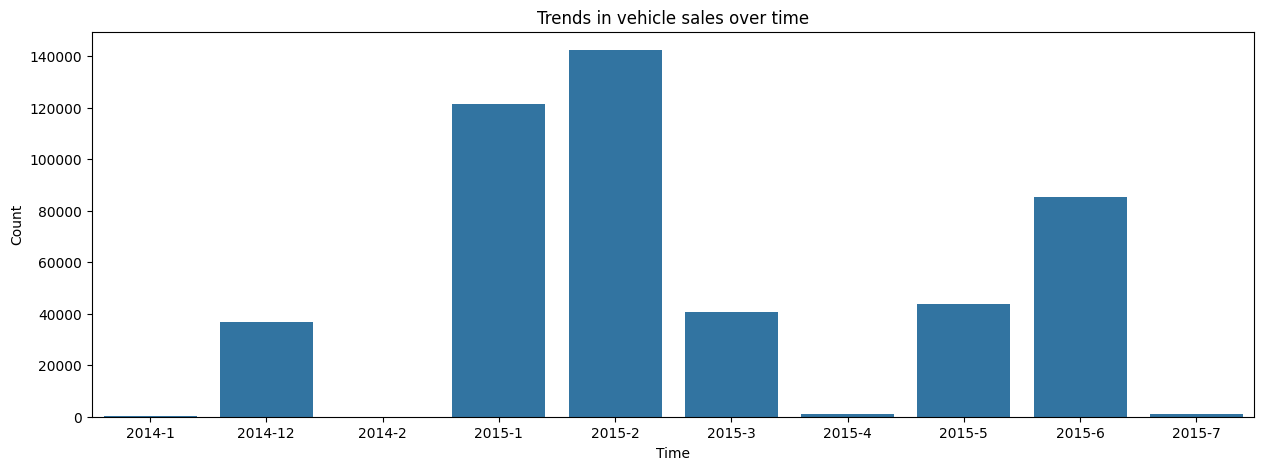

In [ ]:
#Count Plot for Year Distribution
s= df['Time'].value_counts()
plt.figure(figsize=(15,5))
#sns.countplot(x='Year2', data=df, color='blue')
ax=sns.barplot(x=s.index, y=s.values, order=tp)
ax.set_ylabel('Count')
plt.title('Trends in vehicle sales over time')
plt.show()

# Figure 2 and 3

Analyze the impact of vehicle condition and mileage on selling prices

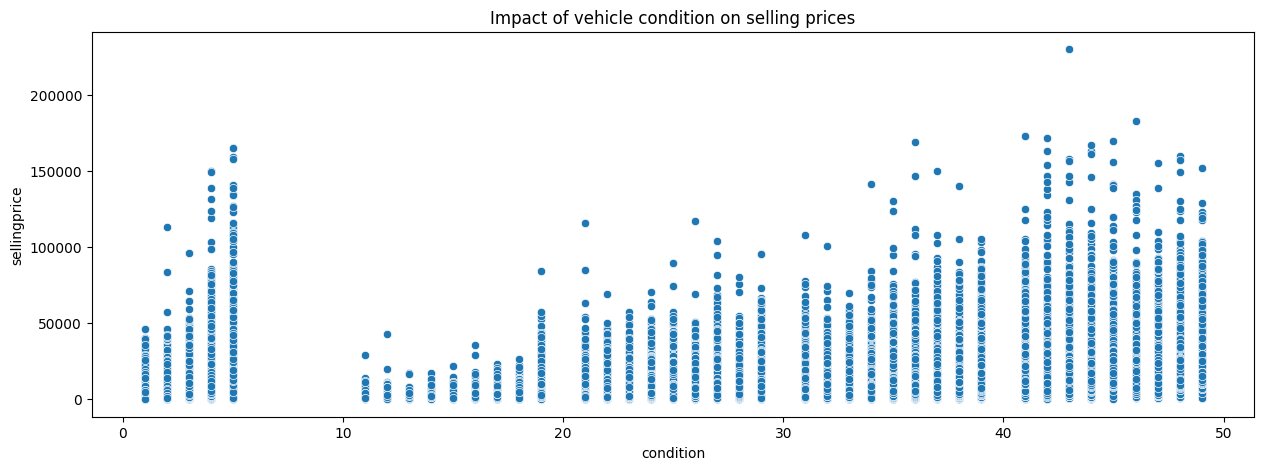

In [ ]:
#Scatter Plot for Total Crashes According to Year
plt.figure(figsize=(15,5))
sns.scatterplot(x='condition', y= 'sellingprice', data=df)
plt.title('Impact of vehicle condition on selling prices')
plt.show()


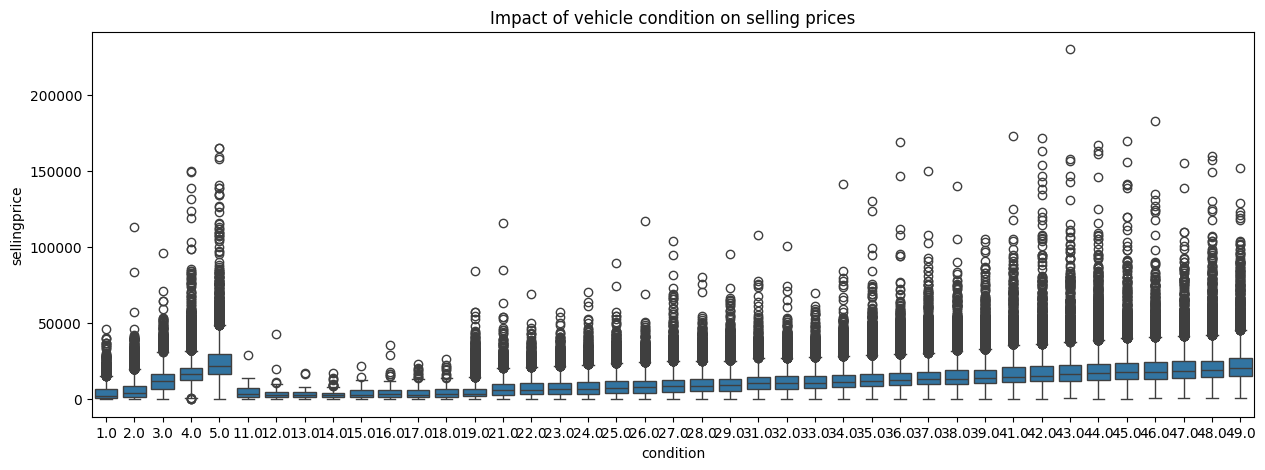

In [ ]:
#Box Plot for Total Crashes according to Quarter
plt.figure(figsize=(15,5))
sns.boxplot(x='condition', y= 'sellingprice', data=df )
plt.title('Impact of vehicle condition on selling prices')
plt.show()

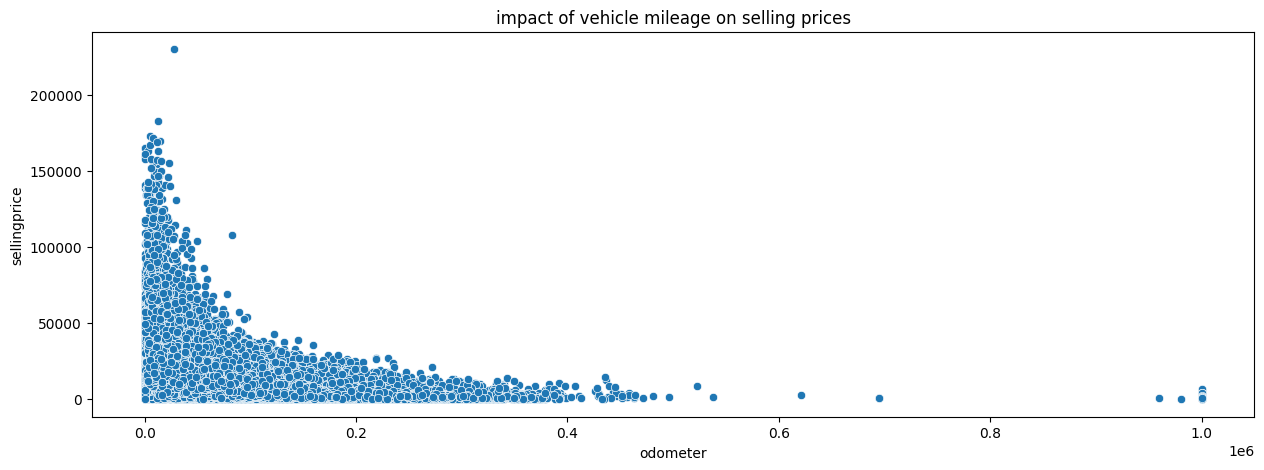

In [ ]:
#Scatter Plot for Total Crashes According to Year
plt.figure(figsize=(15,5))
sns.scatterplot(x='odometer', y= 'sellingprice', data=df)
plt.title('Impact of vehicle mileage on selling prices')
plt.show()


# figure 4
Understand the relationship between MMR values and actual selling prices.

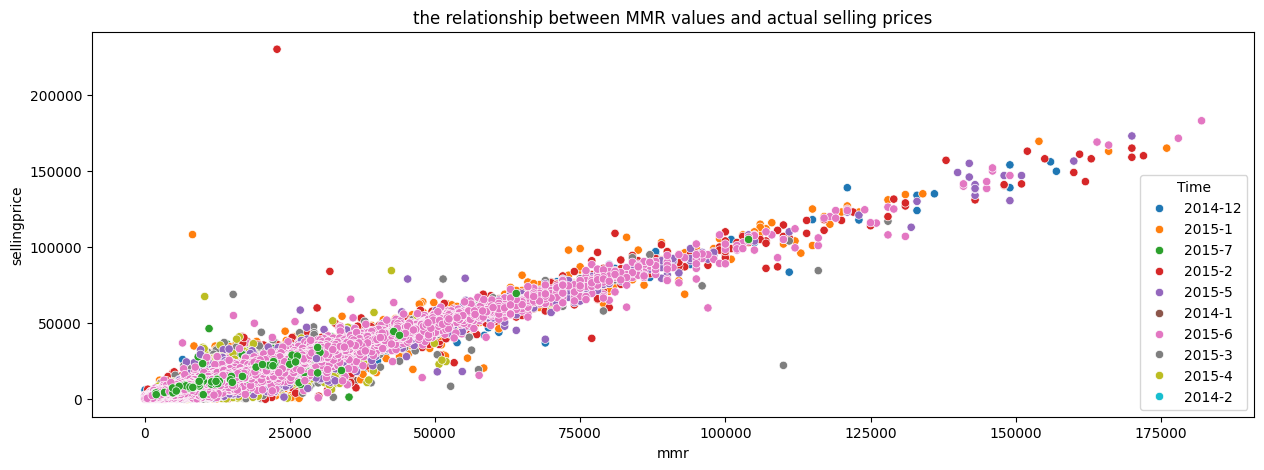

In [ ]:
#Scatter Plot for the relationship between MMR values and actual selling prices
plt.figure(figsize=(15,5))
sns.scatterplot(x='mmr', y= 'sellingprice', data=df, hue='Time')
plt.title('the relationship between MMR values and actual selling prices')
plt.show()


# figure 5
Determine the most popular vehicle makes and models.


In [ ]:
print(s)
tp=s[:10]
print(tp)


make
Ford             81013
Chevrolet        54150
Nissan           44043
Toyota           35313
Dodge            27181
Honda            24781
Hyundai          18659
BMW              17509
Kia              15828
Chrysler         15133
Infiniti         14011
Mercedes-Benz    14008
Jeep             12735
Volkswagen       10780
Lexus            10409
GMC               9217
Mazda             6930
Cadillac          6315
Lincoln           4926
Audi              4802
Acura             4503
Buick             4470
Subaru            4369
Ram               4044
Pontiac           4018
Mitsubishi        3661
Volvo             3082
MINI              2946
Saturn            2570
Mercury           1571
Scion             1545
Land Rover        1322
Jaguar            1257
Porsche           1157
Suzuki             977
HUMMER             768
FIAT               725
Saab               416
smart              343
Oldsmobile         318
Isuzu              179
Maserati           109
Bentley            105
Aston 

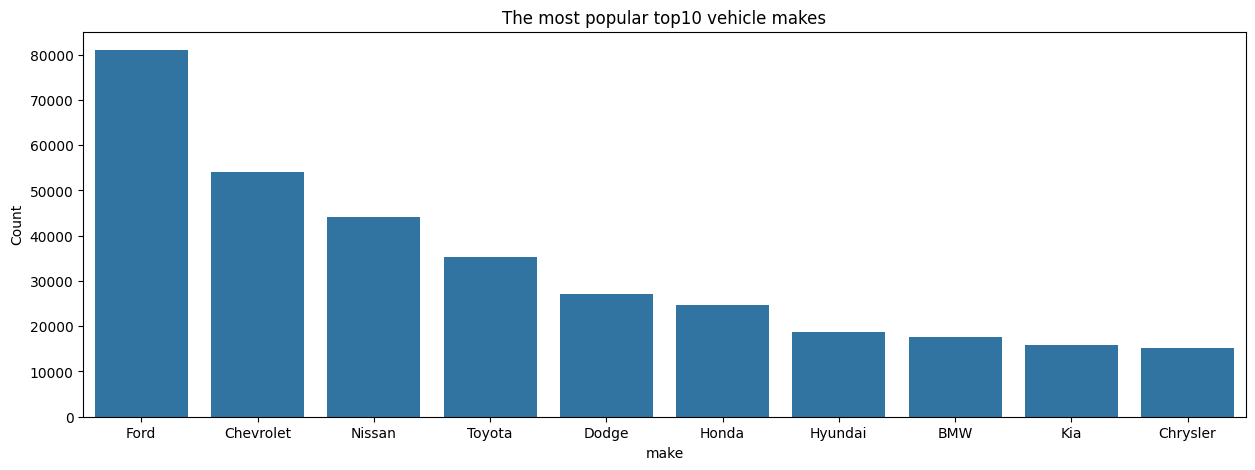

In [ ]:
#Count Plot for Year Distribution
s= df['make'].value_counts()
plt.figure(figsize=(15,5))
ax=sns.barplot(x=s.index[:10], y=s.values[:10])
ax.set_ylabel('Count')
plt.title('The most popular top10 vehicle makes')
plt.show()

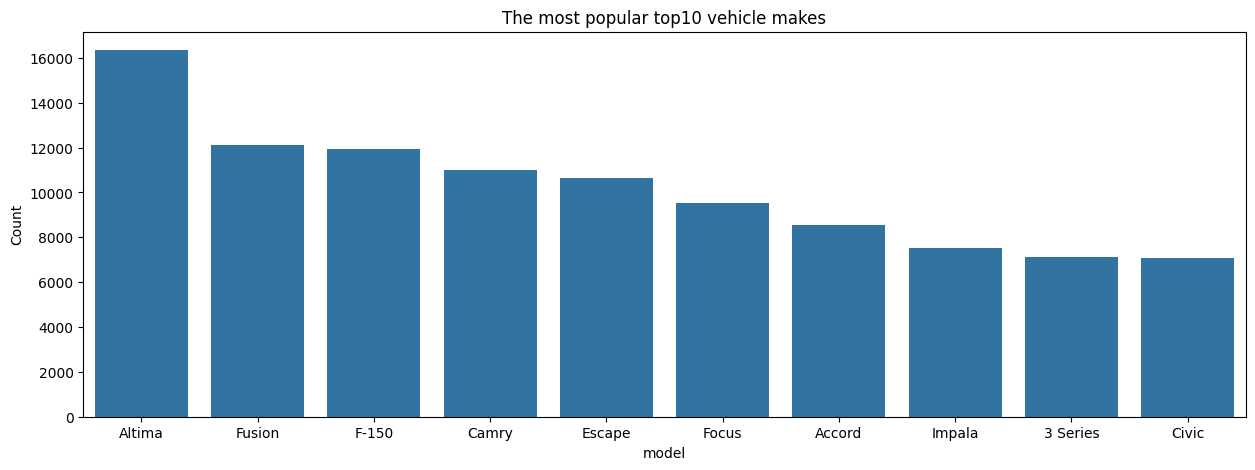

In [ ]:
#Count Plot for Year Distribution
s= df['model'].value_counts()
plt.figure(figsize=(15,5))
ax=sns.barplot(x=s.index[:10], y=s.values[:10])
ax.set_ylabel('Count')
plt.title('The most popular top10 vehicle model')
plt.show()